In [108]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import torch.utils.data as data
import numpy as np
import torchvision
from torchvision import transforms, models
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

import medmnist
from medmnist import INFO, Evaluator

cudnn.benchmark = True
plt.ion()   # interactive mode

In [109]:
data_transforms = {
    'train': transforms.Compose([
        transforms.ToTensor(),
        transforms.RandomHorizontalFlip(),
        # transforms.Normalize(mean=[.5], std=[.5]),
        transforms.Lambda(lambda x: x.expand(3, -1, -1))
    ]),
    'val': transforms.Compose([
        transforms.ToTensor(),
        # transforms.Normalize(mean=[.5], std=[.5]),
        transforms.Lambda(lambda x: x.expand(3, -1, -1))
    ]),
}
# dataset = "breastmnist.npz"
# data_dir = "Datasets"

# data_path =  os.path.join(os.path.dirname(os.getcwd()), data_dir, dataset)
# if os.path.exists(data_path):
#     print(data_path)

data_flag = "breastmnist"
info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

# epochs, batch size and learning rate
NUM_EPOCHS = 30
BATCH_SIZE = 8

# load the data and transform data, storing train and val data into dictionary
DataClass = getattr(medmnist, info['python_class'])

image_datasets = {x: DataClass(split=x, transform=data_transforms[x], download=False)
                  for x in ['train', 'val']}

dataloaders = {x: data.DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True)
               for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

class_names = {
    0: "malignant",
    1: "normal, benign"
}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

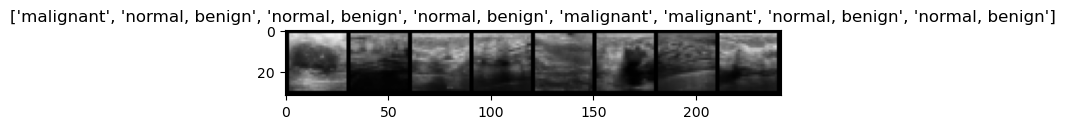

In [110]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    # change from (C,H,W) to (H, W, C)
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x.item()] for x in classes])

In [111]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    labels = labels.squeeze()
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [112]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j].item()]}, actual: {class_names[labels[j].item()]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [113]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [114]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=NUM_EPOCHS)

Epoch 0/29
----------
train Loss: 0.7507 Acc: 0.7253
val Loss: 0.7890 Acc: 0.7179

Epoch 1/29
----------
train Loss: 0.5848 Acc: 0.7747
val Loss: 0.4084 Acc: 0.8462

Epoch 2/29
----------
train Loss: 0.5446 Acc: 0.7729
val Loss: 0.5531 Acc: 0.7949

Epoch 3/29
----------
train Loss: 0.6414 Acc: 0.7527
val Loss: 0.3420 Acc: 0.8590

Epoch 4/29
----------
train Loss: 0.5451 Acc: 0.7619
val Loss: 0.3424 Acc: 0.8590

Epoch 5/29
----------
train Loss: 0.5220 Acc: 0.7875
val Loss: 0.5413 Acc: 0.7949

Epoch 6/29
----------
train Loss: 0.4255 Acc: 0.8278
val Loss: 0.3600 Acc: 0.8718

Epoch 7/29
----------
train Loss: 0.4325 Acc: 0.8168
val Loss: 0.3027 Acc: 0.8846

Epoch 8/29
----------
train Loss: 0.3733 Acc: 0.8590
val Loss: 0.3203 Acc: 0.8590

Epoch 9/29
----------
train Loss: 0.3425 Acc: 0.8608
val Loss: 0.3431 Acc: 0.8718

Epoch 10/29
----------
train Loss: 0.3744 Acc: 0.8315
val Loss: 0.3008 Acc: 0.8718

Epoch 11/29
----------
train Loss: 0.3346 Acc: 0.8626
val Loss: 0.3190 Acc: 0.8718

Ep

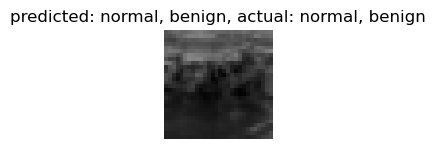

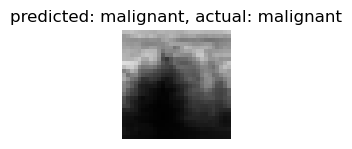

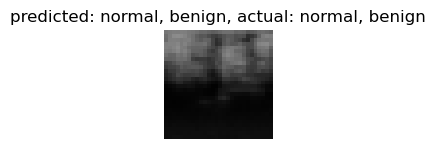

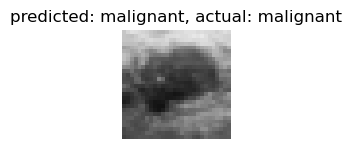

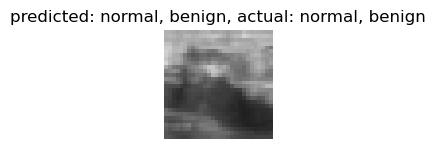

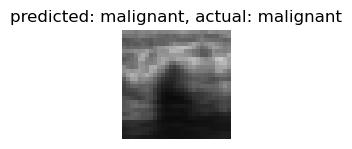

In [115]:
visualize_model(model_ft)

# Testing and testing acc

In [122]:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Lambda(lambda x: x.expand(3, -1, -1))])

test_dataset = DataClass(split="test", transform=transform, download=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [123]:
def test_accuracy(model):
    model.eval()
    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            labels = labels.squeeze()
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            running_corrects += torch.sum(preds == labels.data)
            total_samples += labels.size(0)
    
    accuracy = running_corrects.double()/total_samples
    print(f"test accuracy: {accuracy}")

            

In [124]:
test_accuracy(model_ft)

test accuracy: 0.8397435897435898


# Saving the model

In [ ]:
# Print model's state_dict
print("Model's state_dict:")
for param_tensor in model_ft.state_dict():
    print(param_tensor, "\t", model_ft.state_dict()[param_tensor].size())

# Print optimizer's state_dict
print("Optimizer's state_dict:")
for var_name in optimizer_ft.state_dict():
    print(var_name, "\t", optimizer_ft.state_dict()[var_name])

In [132]:
def save_model_weights(model, model_filename="cnn_model_weights.pt"):
    model_path = os.path.join(os.getcwd(), model_filename)

    torch.save(model.state_dict(), model_path)
    print(f"Model weights have been saved to {model_filename}")

In [133]:
save_model_weights(model_ft)

Model weights have been saved to cnn_model_weights.pt


In [134]:
def load_model(file_path):
    model = torch.load(file_path, weights_only = False)

    return model

In [ ]:
loaded_model = load_model("cnn_model_weights.pt")
test_accuracy(loaded_model)